In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor

In [2]:
df = pd.read_csv('healthcare_dataset.csv')

X = df[['Age', 'Billing Amount']]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df['anomaly'] = lof.fit_predict(x_scaled)

anomalies = df[df['anomaly'] == -1]

print("total anomalies", len(anomalies))
print(anomalies.head())


total anomalies 2775
                  Name  Age  Gender Blood Type Medical Condition  \
7   CHrisTInA MARtinez   20  Female         A+            Cancer   
15  MS. nAtalIE gAMble   46  Female        AB-           Obesity   
19      dANIEL schmIdt   63    Male         B+            Asthma   
20       tIMOTHY burNs   67  Female         A-            Asthma   
37  CasSAndrA Robinson   26  Female         B-      Hypertension   

   Date of Admission           Doctor                     Hospital  \
7         2021-12-28   Suzanne Thomas  Powell Robinson and Valdez,   
15        2023-01-01  Maria Dougherty               Cline-Williams   
19        2022-11-15  Denise Galloway                  Hammond Ltd   
20        2023-06-28     Krista Smith                    Jones LLC   
37        2021-12-19   Travis Parsons               Espinoza-Stone   

   Insurance Provider  Billing Amount  Room Number Admission Type  \
7               Cigna    45820.462722          277      Emergency   
15         

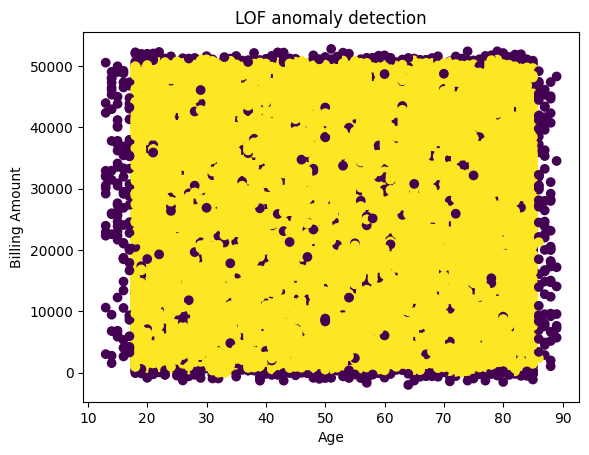

In [3]:
plt.scatter(df['Age'], df['Billing Amount'], c = df['anomaly'])
plt.xlabel("Age")
plt.ylabel("Billing Amount")
plt.title("LOF anomaly detection")
plt.show()